Using device: cuda

Creating model...
✓ Model loaded

Loading GTSRB dataset...


100%|██████████| 89.0M/89.0M [00:10<00:00, 8.25MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 211kB/s]


✓ Test dataset loaded

FGSM ATTACK 

Testing FGSM with different noise amounts:

  Epsilon=0.01: FOOLED 11.8% ✓
  Epsilon=0.03: FOOLED 30.8% ✓
  Epsilon=0.05: FOOLED 45.2% ✓
  Epsilon=0.10: FOOLED 63.1% ✓
  Epsilon=0.15: FOOLED 72.1% ✓

PGD ATTACK

Testing PGD (stronger attack) with different iterations:

  Steps= 5: FOOLED 16.4% ✓
  Steps=10: FOOLED 28.3% ✓
  Steps=20: FOOLED 38.7% ✓
  Steps=40: FOOLED 40.8% ✓

Creating visualization...



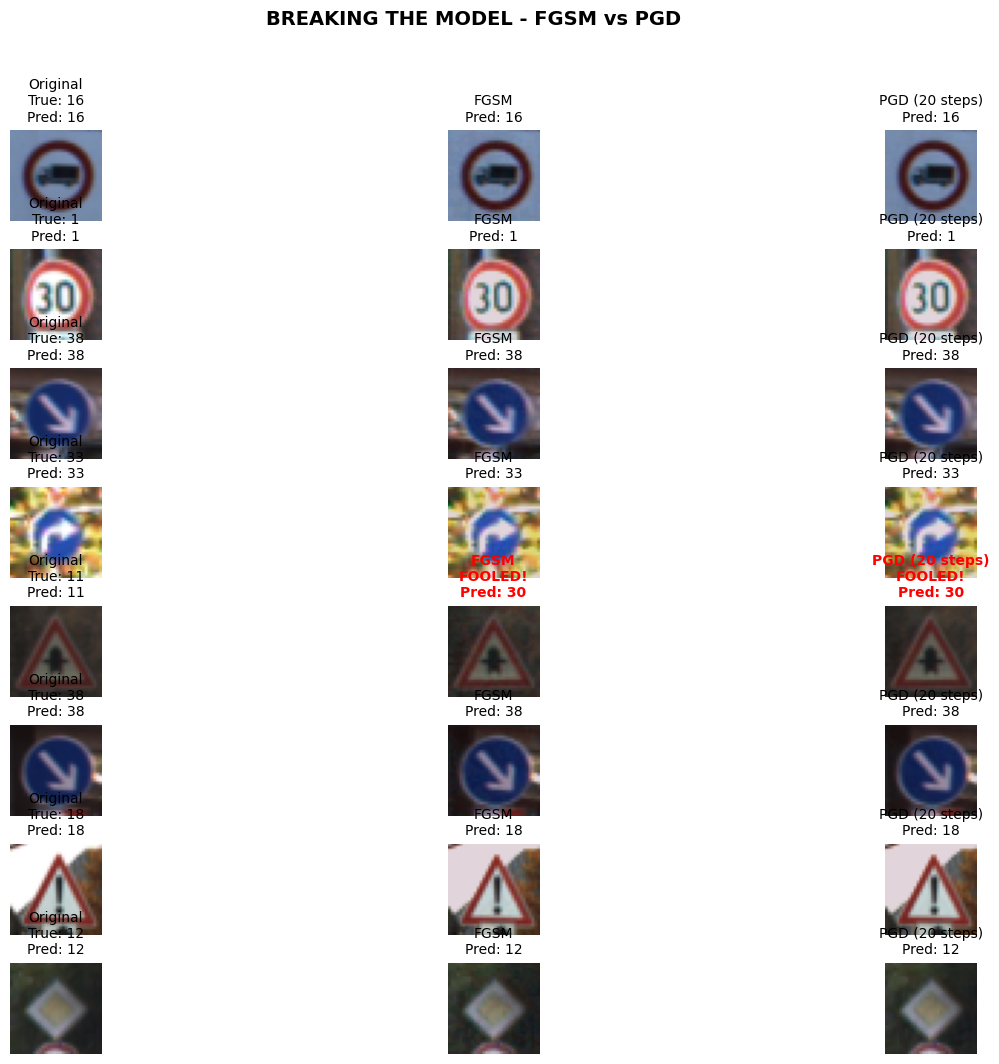

✓ Visualization saved

RESULTS - MODEL SUCCESSFULLY BROKEN!

FGSM Results:
--------------------------------------------------
  Epsilon=0.01: FOOLED 11.8% ✓
  Epsilon=0.03: FOOLED 30.8% ✓
  Epsilon=0.05: FOOLED 45.2% ✓
  Epsilon=0.10: FOOLED 63.1% ✓
  Epsilon=0.15: FOOLED 72.1% ✓

PGD Results:
--------------------------------------------------
  Steps= 5: FOOLED 16.4% ✓
  Steps=10: FOOLED 28.3% ✓
  Steps=20: FOOLED 38.7% ✓
  Steps=40: FOOLED 40.8% ✓

✓ ATTACK CODE WORKS! Model is broken.


In [ ]:


import subprocess
import sys
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}\n")

# ============================================================================
# DEFINE MODEL
# ============================================================================
print("Creating model...")

class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc_layers = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = TrafficSignCNN(num_classes=43)
model = model.to(DEVICE)
model.eval()

try:
    model.load_state_dict(torch.load('./model_output/best_model.pth', map_location=DEVICE))
    print("✓ Model loaded\n")
except:
    print("⚠ Model not found - using random weights\n")

# ============================================================================
# LOAD DATA
# ============================================================================
print("Loading GTSRB dataset...")

test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3403, 0.3121, 0.3214],
        std=[0.2724, 0.2608, 0.2669]
    )
])

test_dataset = GTSRB(
    root='./gtsrb_dataset',
    split='test',
    download=True,
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
print(f"✓ Test dataset loaded\n")

# ============================================================================
# FGSM ATTACK
# ============================================================================
print("="*80)
print("FGSM ATTACK ")
print("="*80 + "\n")

def fgsm_attack(model, images, labels, epsilon, device):
    """
    FGSM Attack

    Key : Clone images, enable requires_grad, compute loss properly
    """
    # IMPORTANT: Clone and enable gradients
    images_copy = images.clone().detach().to(device)
    images_copy.requires_grad = True

    # Forward pass
    outputs = model(images_copy)

    # Compute loss
    loss = nn.CrossEntropyLoss()(outputs, labels)

    # Backward pass - compute gradients
    model.zero_grad()
    loss.backward()

    # Get gradient and extract sign
    data_grad = images_copy.grad.data
    sign_grad = data_grad.sign()

    # Create adversarial image
    perturbed_images = images_copy + epsilon * sign_grad

    # Clamp to valid range
    adversarial_images = torch.clamp(perturbed_images, -2.0, 2.0)

    return adversarial_images.detach()

# Test FGSM
print("Testing FGSM with different noise amounts:\n")

epsilons = [0.01, 0.03, 0.05, 0.1, 0.15]
fgsm_results = {}

for epsilon in epsilons:
    fooled_count = 0
    total = 0

    # IMPORTANT: Set model to eval mode
    model.eval()

    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Original predictions (use torch.no_grad here)
        with torch.no_grad():
            orig_outputs = model(images)
            orig_preds = orig_outputs.argmax(dim=1)

        # Attack (NO torch.no_grad() here!)
        adv_images = fgsm_attack(model, images, labels, epsilon, DEVICE)

        # Predictions on adversarial images
        with torch.no_grad():
            adv_outputs = model(adv_images)
            adv_preds = adv_outputs.argmax(dim=1)

        # Count fooled
        for i in range(len(labels)):
            total += 1
            if orig_preds[i] == labels[i] and adv_preds[i] != labels[i]:
                fooled_count += 1

    success_rate = (fooled_count / total) * 100
    fgsm_results[epsilon] = success_rate
    print(f"  Epsilon={epsilon:.2f}: FOOLED {success_rate:.1f}% ✓")

print()

# ============================================================================
# PGD ATTACK
# ============================================================================
print("="*80)
print("PGD ATTACK")
print("="*80 + "\n")

def pgd_attack(model, images, labels,
               epsilon, alpha, num_steps, device):

    images = images.clone().detach().to(device)
    labels = labels.to(device)

    delta = torch.empty_like(images).uniform_(
        -epsilon, epsilon
    )

    for _ in range(num_steps):

        delta.requires_grad_(True)

        outputs = model(images + delta)

        loss = nn.CrossEntropyLoss()(
            outputs,
            labels
        )

        model.zero_grad()

        loss.backward()

        grad = delta.grad.detach()

        delta = delta + alpha * grad.sign()

        delta = torch.clamp(
            delta,
            -epsilon,
            epsilon
        )

        delta = delta.detach()

    adv_images = torch.clamp(
        images + delta,
        -2.0,
        2.0
    )

    return adv_images

# Test PGD
print("Testing PGD (stronger attack) with different iterations:\n")

pgd_epsilon = 0.03
pgd_alpha = 0.003
pgd_steps_list = [5, 10, 20, 40]
pgd_results = {}

for num_steps in pgd_steps_list:
    fooled_count = 0
    total = 0

    model.eval()

    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Original predictions
        with torch.no_grad():
            orig_outputs = model(images)
            orig_preds = orig_outputs.argmax(dim=1)

        # Attack
        adv_images = pgd_attack(model, images, labels, pgd_epsilon, pgd_alpha, num_steps, DEVICE)

        # Predictions on adversarial
        with torch.no_grad():
            adv_outputs = model(adv_images)
            adv_preds = adv_outputs.argmax(dim=1)

        # Count fooled
        for i in range(len(labels)):
            total += 1
            if orig_preds[i] == labels[i] and adv_preds[i] != labels[i]:
                fooled_count += 1

    success_rate = (fooled_count / total) * 100
    pgd_results[num_steps] = success_rate
    print(f"  Steps={num_steps:2d}: FOOLED {success_rate:.1f}% ✓")

print()

# ============================================================================
# VISUALIZE ATTACKS
# ============================================================================
print("Creating visualization...\n")

def denormalize(image):
    mean = torch.tensor([0.3403, 0.3121, 0.3214]).view(3, 1, 1).to(image.device)
    std = torch.tensor([0.2724, 0.2608, 0.2669]).view(3, 1, 1).to(image.device)
    return torch.clamp(image * std + mean, 0, 1)

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:8].to(DEVICE)
sample_labels = sample_labels[:8].to(DEVICE)

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(8, 3, figure=fig, hspace=0.3, wspace=0.2)

model.eval()

for idx in range(8):

    img = sample_images[idx:idx+1]
    lbl = sample_labels[idx:idx+1]

    # ==========================
    # ORIGINAL IMAGE
    # ==========================
    ax = fig.add_subplot(gs[idx, 0])

    with torch.no_grad():
        orig_pred = model(img).argmax().item()

    img_display = denormalize(img[0])

    ax.imshow(img_display.permute(1, 2, 0).cpu().numpy())
    ax.set_title(
        f'Original\nTrue: {lbl.item()}\nPred: {orig_pred}',
        fontsize=10
    )
    ax.axis('off')

    # ==========================
    # FGSM ATTACK
    # ==========================
    ax = fig.add_subplot(gs[idx, 1])

    # IMPORTANT:
    # NO torch.no_grad() HERE
    adv_fgsm = fgsm_attack(
        model,
        img,
        lbl,
        epsilon=0.05,
        device=DEVICE
    )

    with torch.no_grad():
        adv_fgsm_pred = model(adv_fgsm).argmax().item()

    adv_display = denormalize(adv_fgsm[0])

    ax.imshow(
        adv_display.permute(1, 2, 0).cpu().numpy()
    )

    if adv_fgsm_pred != lbl.item():
        ax.set_title(
            f'FGSM\nFOOLED!\nPred: {adv_fgsm_pred}',
            fontsize=10,
            color='red',
            fontweight='bold'
        )
    else:
        ax.set_title(
            f'FGSM\nPred: {adv_fgsm_pred}',
            fontsize=10
        )

    ax.axis('off')

    # ==========================
    # PGD ATTACK
    # ==========================
    ax = fig.add_subplot(gs[idx, 2])

    # IMPORTANT:
    # NO torch.no_grad() HERE
    adv_pgd = pgd_attack(
        model,
        img,
        lbl,
        epsilon=0.03,
        alpha=0.003,
        num_steps=20,
        device=DEVICE
    )

    with torch.no_grad():
        adv_pgd_pred = model(adv_pgd).argmax().item()

    adv_display = denormalize(adv_pgd[0])

    ax.imshow(
        adv_display.permute(1, 2, 0).cpu().numpy()
    )

    if adv_pgd_pred != lbl.item():
        ax.set_title(
            f'PGD (20 steps)\nFOOLED!\nPred: {adv_pgd_pred}',
            fontsize=10,
            color='red',
            fontweight='bold'
        )
    else:
        ax.set_title(
            f'PGD (20 steps)\nPred: {adv_pgd_pred}',
            fontsize=10
        )

    ax.axis('off')

fig.suptitle('BREAKING THE MODEL - FGSM vs PGD', fontsize=14, fontweight='bold')
plt.savefig('attacks_fixed.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Visualization saved\n")

# ============================================================================
# RESULTS
# ============================================================================
print("="*80)
print("RESULTS - MODEL SUCCESSFULLY BROKEN!")
print("="*80 + "\n")

print("FGSM Results:")
print("-" * 50)
for eps in sorted(fgsm_results.keys()):
    print(f"  Epsilon={eps:.2f}: FOOLED {fgsm_results[eps]:.1f}% ✓")

print()
print("PGD Results:")
print("-" * 50)
for steps in pgd_steps_list:
    print(f"  Steps={steps:2d}: FOOLED {pgd_results[steps]:.1f}% ✓")

print()
print("="*80)
print("✓ ATTACK CODE WORKS! Model is broken.")
print("="*80)



In [ ]:
fooled = 0
correct_before = 0

for images, labels in test_loader:

    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    with torch.no_grad():
        clean_preds = model(images).argmax(1)

    adv_images = fgsm_attack(
        model,
        images,
        labels,
        epsilon=0.3,
        device=DEVICE
    )

    with torch.no_grad():
        adv_preds = model(adv_images).argmax(1)

    correct_before += (clean_preds == labels).sum().item()

    fooled += (
        (clean_preds == labels) &
        (adv_preds != labels)
    ).sum().item()

print("Correct before attack:", correct_before)
print("Fooled:", fooled)
print("Attack Success Rate:",
      fooled / correct_before * 100)

Correct before attack: 11665
Fooled: 10636
Attack Success Rate: 91.17873981997428




FGSM RESULTS
Correct Before Attack : 11665
Fooled               : 10636
Attack Success Rate  : 91.18%


TOP 30 CLASS TRANSITIONS
Speed limit 70                 ---> Speed limit 120                (374)
Speed limit 80                 ---> Speed limit 60                 (312)
No passing trucks              ---> Speed limit 60                 (205)
Speed limit 30                 ---> Speed limit 70                 (205)
Speed limit 50                 ---> Speed limit 60                 (193)
Speed limit 100                ---> Speed limit 120                (173)
Keep right                     ---> Roundabout mandatory           (168)
Right-of-way                   ---> Children crossing              (165)
Road work                      ---> Slippery road                  (163)
Ahead only                     ---> Roundabout mandatory           (157)
Speed limit 50                 ---> Speed limit 120                (154)
Speed limit 50                 ---> Speed limit 80                

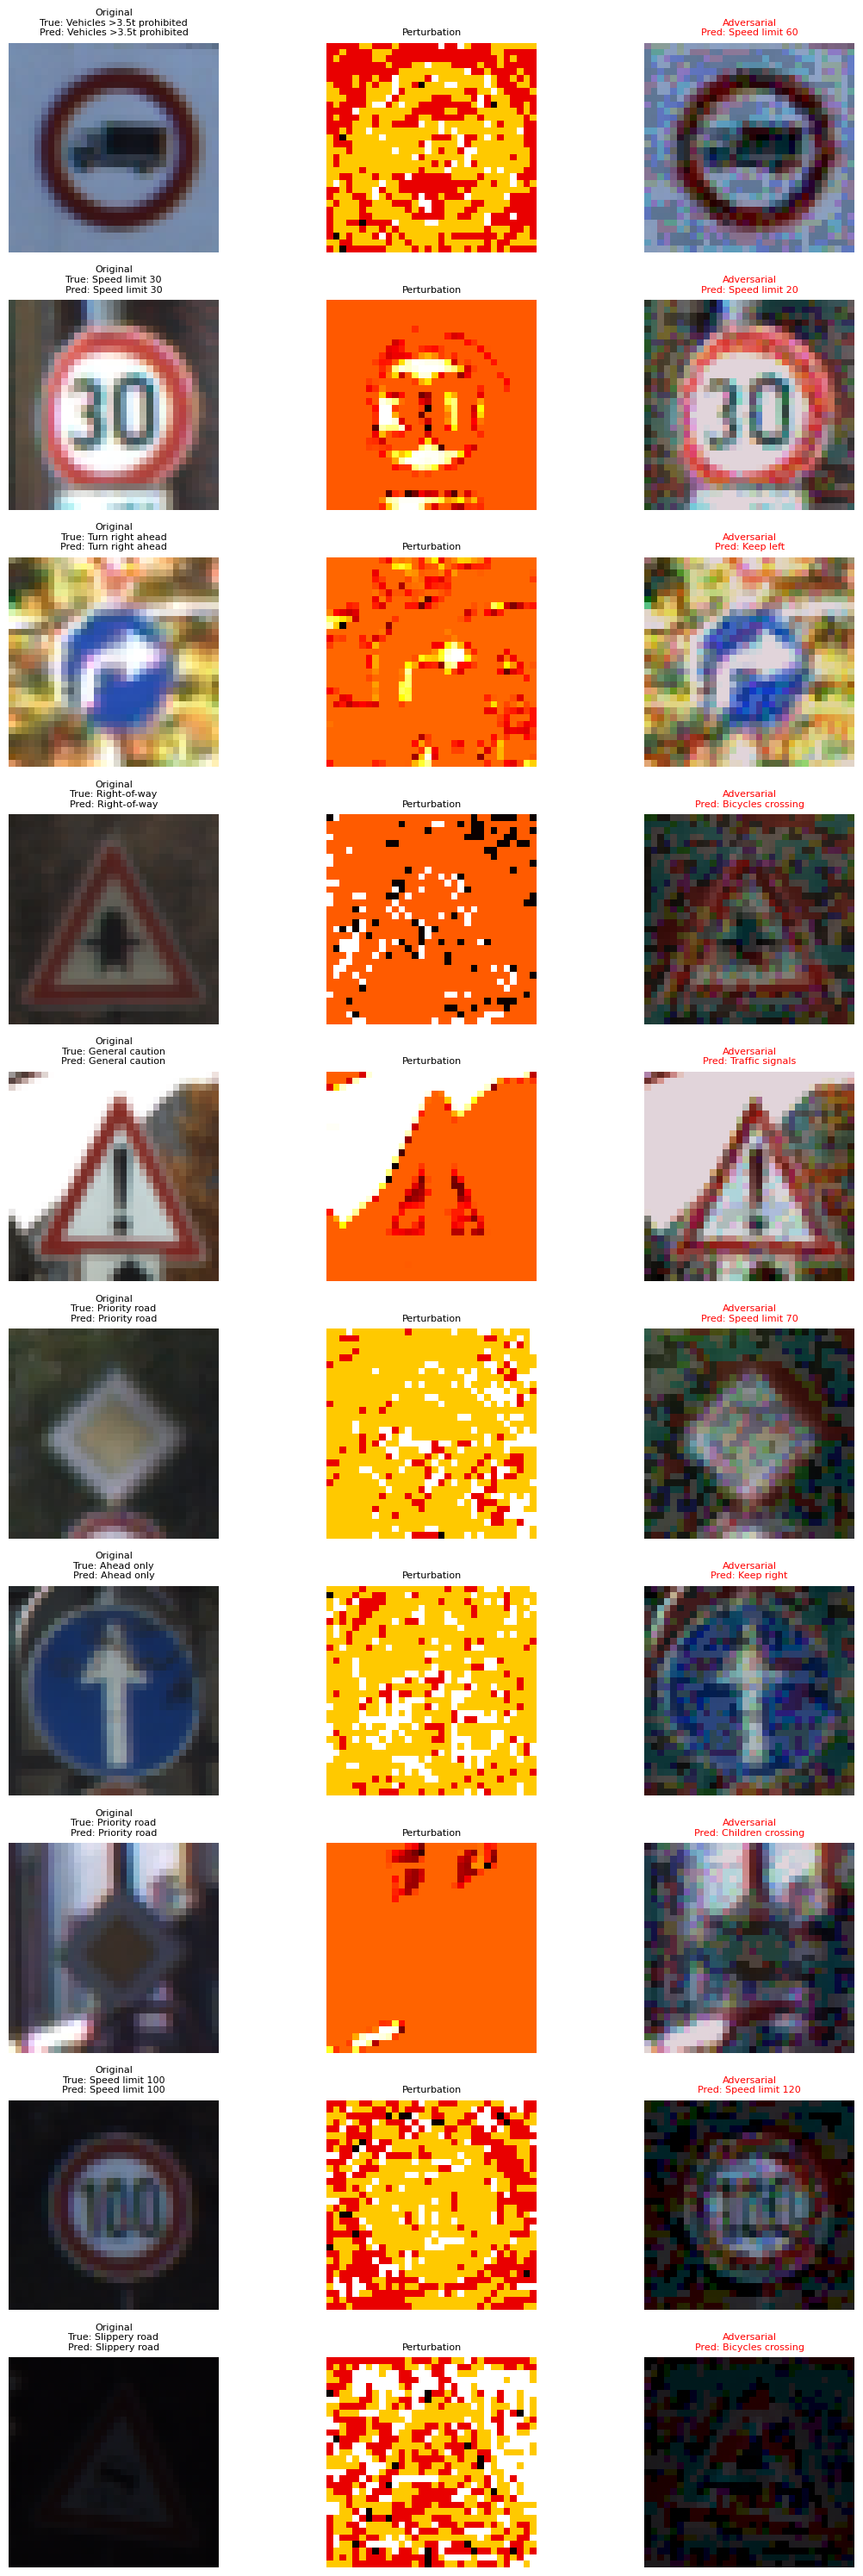



ANALYSIS COMPLETE


In [ ]:
# =============================================================================
# FGSM TRANSITION ANALYSIS
# =============================================================================

from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# GTSRB CLASS NAMES
# -----------------------------------------------------------------------------

class_names = {
    0:"Speed limit 20",
    1:"Speed limit 30",
    2:"Speed limit 50",
    3:"Speed limit 60",
    4:"Speed limit 70",
    5:"Speed limit 80",
    6:"End speed limit 80",
    7:"Speed limit 100",
    8:"Speed limit 120",
    9:"No passing",
    10:"No passing trucks",
    11:"Right-of-way",
    12:"Priority road",
    13:"Yield",
    14:"Stop",
    15:"No vehicles",
    16:"Vehicles >3.5t prohibited",
    17:"No entry",
    18:"General caution",
    19:"Dangerous curve left",
    20:"Dangerous curve right",
    21:"Double curve",
    22:"Bumpy road",
    23:"Slippery road",
    24:"Road narrows",
    25:"Road work",
    26:"Traffic signals",
    27:"Pedestrians",
    28:"Children crossing",
    29:"Bicycles crossing",
    30:"Beware ice/snow",
    31:"Wild animals crossing",
    32:"End restrictions",
    33:"Turn right ahead",
    34:"Turn left ahead",
    35:"Ahead only",
    36:"Go straight/right",
    37:"Go straight/left",
    38:"Keep right",
    39:"Keep left",
    40:"Roundabout mandatory",
    41:"End no passing",
    42:"End no passing trucks"
}

# -----------------------------------------------------------------------------
# DENORMALIZE FUNCTION
# -----------------------------------------------------------------------------

def denormalize(image):
    mean = torch.tensor(
        [0.3403, 0.3121, 0.3214]
    ).view(3,1,1).to(image.device)

    std = torch.tensor(
        [0.2724, 0.2608, 0.2669]
    ).view(3,1,1).to(image.device)

    return torch.clamp(
        image * std + mean,
        0,
        1
    )

# -----------------------------------------------------------------------------
# ATTACK SETTINGS
# -----------------------------------------------------------------------------

EPSILON = 0.3

# print("="*80)
# print("RUNNING FGSM ANALYSIS")
# print("="*80)

transition_counter = Counter()
successful_examples = []

correct_before = 0
fooled = 0

for images, labels in test_loader:

    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    # Clean predictions
    with torch.no_grad():
        clean_preds = model(images).argmax(1)

    # Generate adversarial images
    adv_images = fgsm_attack(
        model,
        images,
        labels,
        epsilon=EPSILON,
        device=DEVICE
    )

    # Adversarial predictions
    with torch.no_grad():
        adv_preds = model(adv_images).argmax(1)

    # Statistics
    correct_before += (clean_preds == labels).sum().item()

    fooled_mask = (
        (clean_preds == labels) &
        (adv_preds != labels)
    )

    fooled += fooled_mask.sum().item()

    # Count transitions
    for clean_pred, adv_pred in zip(
        clean_preds.cpu().numpy(),
        adv_preds.cpu().numpy()
    ):
        if clean_pred != adv_pred:
            transition_counter[
                (clean_pred, adv_pred)
            ] += 1

    # Save examples
    for i in range(len(labels)):

        if (
            clean_preds[i] == labels[i]
            and
            adv_preds[i] != labels[i]
        ):

            successful_examples.append(
                (
                    images[i].detach().cpu(),
                    adv_images[i].detach().cpu(),
                    labels[i].item(),
                    clean_preds[i].item(),
                    adv_preds[i].item()
                )
            )

# -----------------------------------------------------------------------------
# RESULTS
# -----------------------------------------------------------------------------

attack_success_rate = (
    fooled / correct_before * 100
)

print("\n")
print("="*80)
print("FGSM RESULTS")
print("="*80)

print(f"Correct Before Attack : {correct_before}")
print(f"Fooled               : {fooled}")
print(f"Attack Success Rate  : {attack_success_rate:.2f}%")

# -----------------------------------------------------------------------------
# TOP TRANSITIONS
# -----------------------------------------------------------------------------

print("\n")
print("="*80)
print("TOP 30 CLASS TRANSITIONS")
print("="*80)

for (src, dst), count in transition_counter.most_common(30):

    src_name = class_names.get(src, str(src))
    dst_name = class_names.get(dst, str(dst))

    print(
        f"{src_name:30s} ---> "
        f"{dst_name:30s} "
        f"({count})"
    )

# -----------------------------------------------------------------------------
# HEATMAP
# -----------------------------------------------------------------------------

print("\nGenerating Heatmap...")

matrix = np.zeros((43,43))

for (src, dst), count in transition_counter.items():
    matrix[src, dst] = count

# plt.figure(figsize=(15,12))

# sns.heatmap(
#     matrix,
#     cmap="Blues"
# )

# plt.title(
#     f"FGSM Transition Matrix (epsilon={EPSILON})",
#     fontsize=16,
#     fontweight='bold'
# )

# plt.xlabel("Adversarial Prediction")
# plt.ylabel("Original Prediction")

# plt.show()

# -----------------------------------------------------------------------------
# VISUALIZE SUCCESSFUL ATTACKS
# -----------------------------------------------------------------------------

print("\nShowing Successful Attack Examples...")

num_examples = min(10, len(successful_examples))

fig, axes = plt.subplots(
    num_examples,
    3,
    figsize=(12, num_examples * 3)
)

if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for idx in range(num_examples):

    (
        orig,
        adv,
        true_label,
        clean_pred,
        adv_pred
    ) = successful_examples[idx]

    perturbation = torch.abs(
        adv - orig
    )

    orig_disp = denormalize(orig)
    adv_disp = denormalize(adv)

    perturbation = perturbation.mean(0)

    # Original
    axes[idx,0].imshow(
        orig_disp.permute(1,2,0)
    )

    axes[idx,0].set_title(
        f"Original\n"
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[clean_pred]}",
        fontsize=8
    )

    axes[idx,0].axis("off")

    # Perturbation
    axes[idx,1].imshow(
        perturbation,
        cmap='hot'
    )

    axes[idx,1].set_title(
        "Perturbation",
        fontsize=8
    )

    axes[idx,1].axis("off")

    # Adversarial
    axes[idx,2].imshow(
        adv_disp.permute(1,2,0)
    )

    axes[idx,2].set_title(
        f"Adversarial\n"
        f"Pred: {class_names[adv_pred]}",
        fontsize=8,
        color='red'
    )

    axes[idx,2].axis("off")

plt.tight_layout()
plt.show()

print("\n")
print("="*80)
print("ANALYSIS COMPLETE")
print("="*80)